In [30]:
import requests
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [8]:
lims = [-127.376, -112.412, 31.166, 42.656]

In [9]:
url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
query = {
    "format": "geojson",
    "starttime": '2022-01-01',
    "minmagnitude": '5.5',
    "minlongitude": lims[0],
    "maxlongitude": lims[1],
    "minlatitude": lims[2],
    "maxlatitude": lims[3],
    
}
r = requests.get(url, params=query)

if r.status_code == 200:
    data = r.json()
else: 
    print("error")

In [10]:
data

{'type': 'FeatureCollection',
 'metadata': {'generated': 1780886009000,
  'url': 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2022-01-01&minmagnitude=5.5&minlongitude=-127.376&maxlongitude=-112.412&minlatitude=31.166&maxlatitude=42.656',
  'title': 'USGS Earthquakes',
  'status': 200,
  'api': '2.4.0',
  'count': 8},
 'features': [{'type': 'Feature',
   'properties': {'mag': 5.7,
    'place': '154 km WSW of Pistol River, Oregon',
    'time': 1780484034074,
    'updated': 1780830241050,
    'tz': None,
    'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/us7000sq93',
    'detail': 'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000sq93&format=geojson',
    'felt': 42,
    'cdi': 4.1,
    'mmi': 3.855,
    'alert': 'green',
    'status': 'reviewed',
    'tsunami': 0,
    'sig': 517,
    'net': 'us',
    'code': '7000sq93',
    'ids': ',attg1y9x,us7000sq93,usauto7000sq93,ew1780484060,',
    'sources': ',at,us,usauto,ew,',
    'types': ',

In [11]:
silversprings = data['features'][3]
ss_detail_url = silversprings['properties']['detail']
r2 = requests.get(ss_detail_url)
ss_detail = r2.json()
eew_url = ss_detail['properties']['products']['shake-alert'][-1]['contents']['summary.json']['url']
r3 = requests.get(eew_url)
eew_data = r3.json()


In [19]:
features = eew_data['alerts']
# pprint(eew_data['alerts'])

target_mmi = 4

poly = None
for mmi in range(target_mmi,0,-1):
    print(mmi)
    poly = next((feature for feature in features 
                 if feature['properties'].get('name') == f'MMI {mmi}'))
    if poly:
        break
if poly:
    verts = poly['geometry']['coordinates'][0]
else:
    print("No polygon")

4


StopIteration: 

In [13]:
sa_feats = eew_data['alerts'][['id']=='finalAlertCollection']['features']
pprint(sa_feats)

[{'geometry': {'coordinates': [-119.0873, 39.1805], 'type': 'Point'},
  'id': 'SAinitloc',
  'properties': {'circletime': 0.0,
                 'color': '#000000',
                 'fill-opacity': 1,
                 'radius': 5000.0,
                 'radiusunits': 'm',
                 'title': 'Initial SA Loc',
                 'tunits': 's'},
  'type': 'Feature'},
 {'geometry': {'coordinates': [-119.0326, 39.1634], 'type': 'Point'},
  'id': 'Epicenter',
  'properties': {'icon': 'epicenter', 'title': 'Earthquake Epicenter'},
  'type': 'Feature'},
 {'geometry': {'coordinates': [[[-119.0873, 40.0798],
                                [-118.2595, 39.8135],
                                [-117.9272, 39.1747],
                                [-118.2743, 38.5418],
                                [-119.0873, 38.2812],
                                [-119.9003, 38.5418],
                                [-120.2474, 39.1747],
                                [-119.9151, 39.8135],
            

In [14]:
for feature in sa_feats:
    pprint(feature)
    # print('\n\n\n\n\n\n\n\n\n\n\n')

{'geometry': {'coordinates': [-119.0873, 39.1805], 'type': 'Point'},
 'id': 'SAinitloc',
 'properties': {'circletime': 0.0,
                'color': '#000000',
                'fill-opacity': 1,
                'radius': 5000.0,
                'radiusunits': 'm',
                'title': 'Initial SA Loc',
                'tunits': 's'},
 'type': 'Feature'}
{'geometry': {'coordinates': [-119.0326, 39.1634], 'type': 'Point'},
 'id': 'Epicenter',
 'properties': {'icon': 'epicenter', 'title': 'Earthquake Epicenter'},
 'type': 'Feature'}
{'geometry': {'coordinates': [[[-119.0873, 40.0798],
                               [-118.2595, 39.8135],
                               [-117.9272, 39.1747],
                               [-118.2743, 38.5418],
                               [-119.0873, 38.2812],
                               [-119.9003, 38.5418],
                               [-120.2474, 39.1747],
                               [-119.9151, 39.8135],
                               [-119

In [15]:
target_mmis = np.arange(4.5,0,-0.5)
print(f'MMI {[mmi for mmi in target_mmis]}')

MMI [np.float64(4.5), np.float64(4.0), np.float64(3.5), np.float64(3.0), np.float64(2.5), np.float64(2.0), np.float64(1.5), np.float64(1.0), np.float64(0.5)]


In [16]:
epix, epiy = eew_data['alerts'][['id']=='maxMAlertCollection']['features'][['id']=='Epicenter']['geometry']['coordinates']

In [70]:
gdf = gpd.read_file('./cb_2018_us_county_20m/cb_2018_us_county_20m.shp')
gdf["STATEFP"] = gdf["STATEFP"].astype(str).str.zfill(2)

calnev_counties = gdf[(gdf["STATEFP"] == "06") | (gdf["STATEFP"] == "32")]

/Users/yairfranco/miniforge3/envs/seissol/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


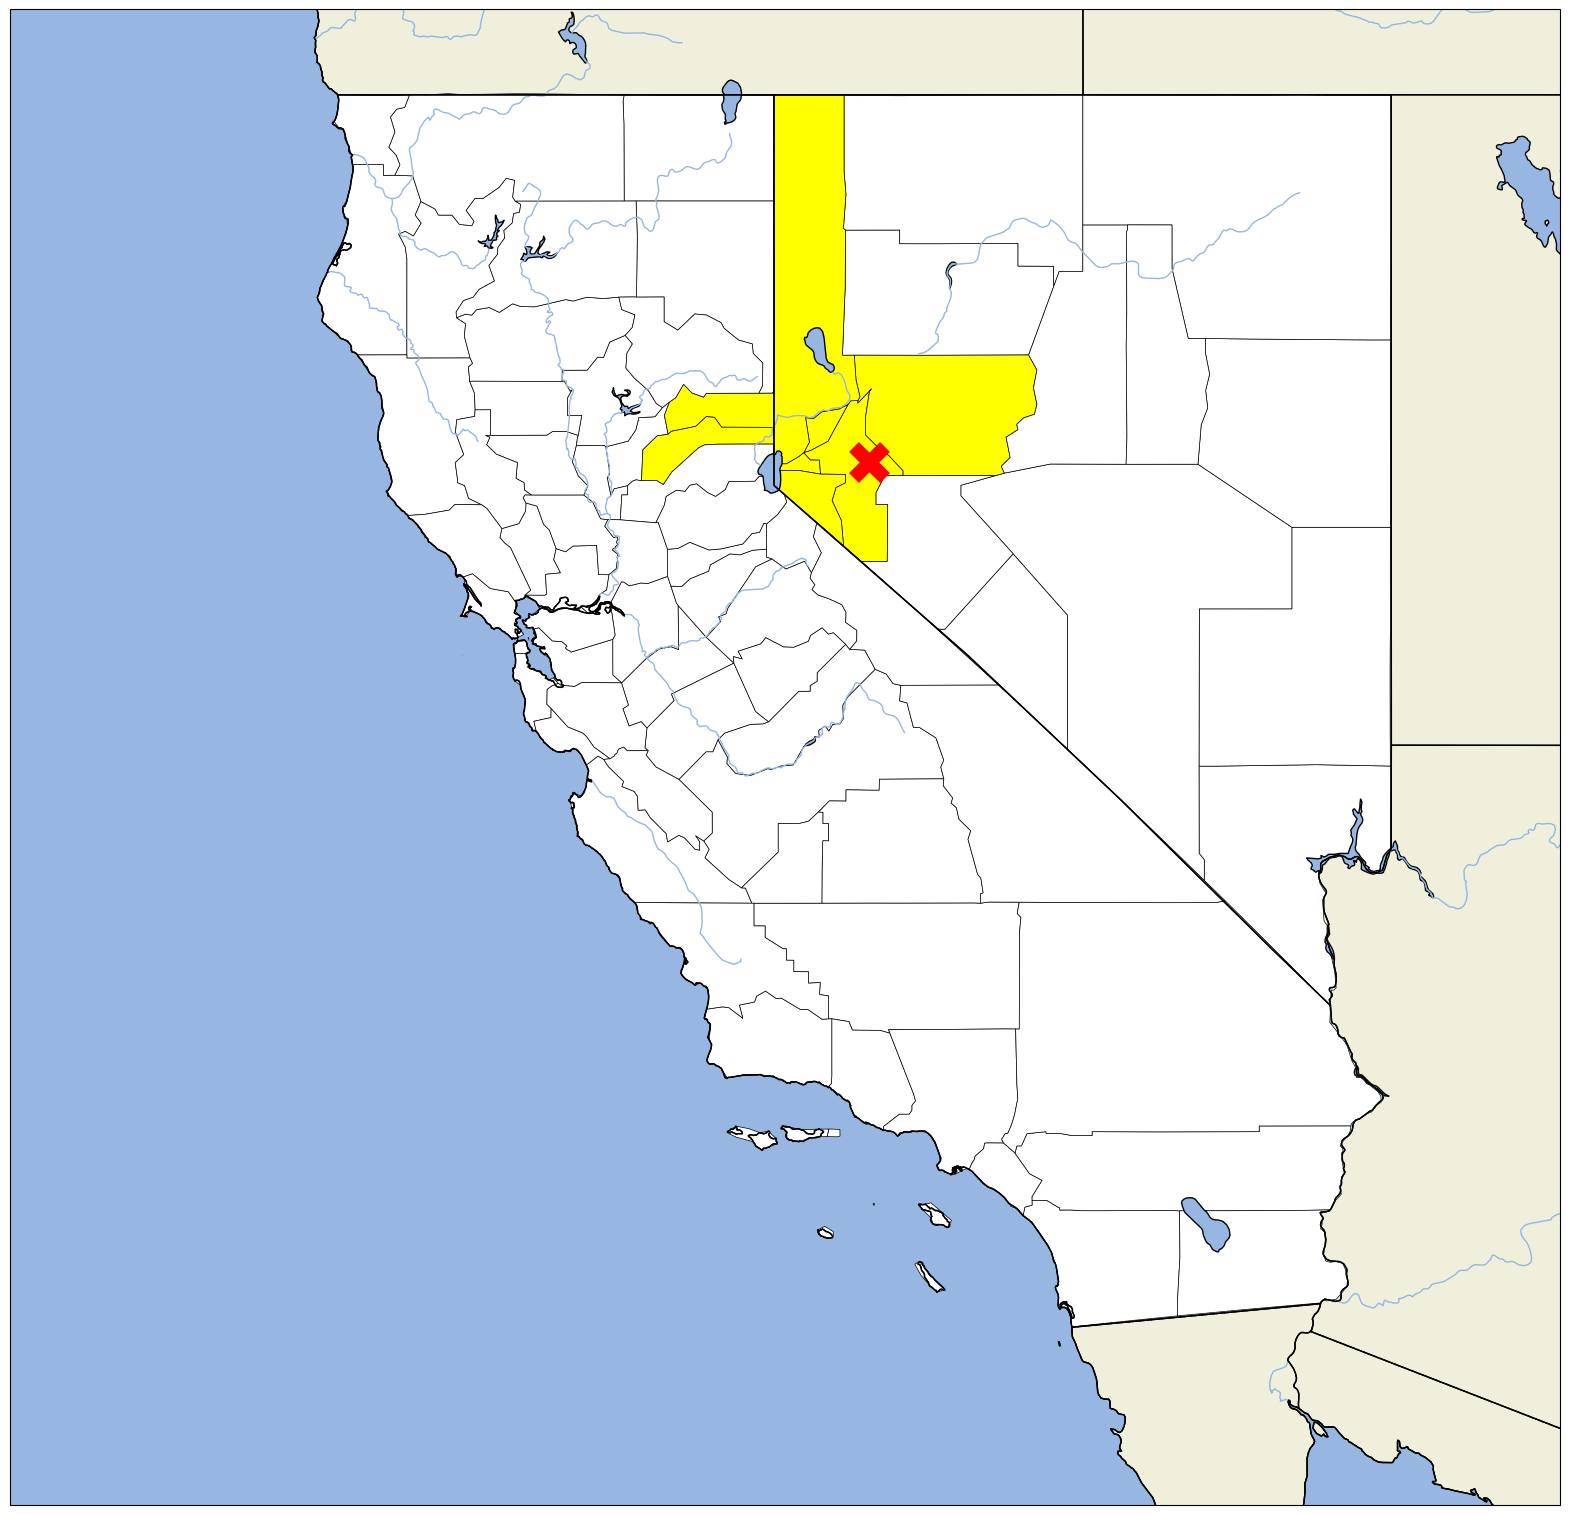

In [69]:
fig, axi = plt.subplots(1,1,figsize=(20,20), subplot_kw={'projection': ccrs.PlateCarree()})

warn_counties = ["Nevada", "Sierra", "Washoe", "Carson City", "Storey", "Churchill", "Lyon", "Douglas"]

calnev_counties['warn'] = calnev_counties['NAME'].isin(warn_counties)
colors = calnev_counties['warn'].map({True: 'yellow', False: 'white'})

calnev_counties.plot(ax=axi,color=colors,edgecolor='black',linewidth=0.5)

axi.set_extent(lims)

axi.add_feature(cfeature.COASTLINE)
axi.add_feature(cfeature.BORDERS, linestyle=':')
axi.add_feature(cfeature.LAND, edgecolor='black')
axi.add_feature(cfeature.LAKES, edgecolor='black')
axi.add_feature(cfeature.RIVERS)
axi.add_feature(cfeature.STATES)
axi.add_feature(cfeature.OCEAN)

axi.scatter(epix,epiy,c='r',marker='x',linewidths=10,s=500)

# eew_poly = Polygon(verts,fill=False,edgecolor='y',linewidth=2)
# axi.add_patch(eew_poly)

In [25]:
eew_url

'https://earthquake.usgs.gov/product/shake-alert/ew1733785720/ew/1733785957832/summary.json'